<div align="center">

<h1> <b> PRESSURE EFFECTS AND GAS-PHASE SCATTERING </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Cristian Vergara <br>
Juan Palacio <br>
Sofía Moscoso <br>
Lucas Perdomo</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>

---

## 1. Introducción y Objetivos

Hasta este punto, hemos asumido que el transporte de adátomos desde la fuente emisora hasta el sustrato ocurre en un régimen puramente balístico lineal (línea de visión). Si bien esta es una aproximación robusta bajo condiciones de vacío ultra-alto (UHV), los reactores de evaporación térmica industriales y de laboratorio operan a presiones finitas donde coexisten moléculas de gas residual (oxígeno, nitrógeno, vapor de agua).

En este sexto notebook, incorporaremos el fenómeno de **Dispersión en Fase Gaseosa (*Gas-Phase Scattering*)** gobernado por el **Camino Libre Medio ($\lambda$)**. El simulador ahora evaluará estocásticamente si el átomo de Cobre colisiona con el gas atmosférico residual antes de impactar contra el relieve, alterando su vector de velocidad original. Este cuaderno unifica toda la física desarrollada previamente en una arquitectura de software modular.

### Objetivos:
* Implementar un modelo cinético de transporte gaseoso donde la distancia entre colisiones siga una distribución estadística exponencial dependiente de la presión de la cámara.
* Analizar la competencia fenomenológica entre el sombreado geométrico (que genera rugosidad) y la dispersión por presión (que redistribuye el flujo hacia los valles).
* Evaluar el comportamiento de las 4 firmas morfológicas de la película delgada al variar el camino libre medio de las partículas evaporadas.

## 2. Fundamento Físico: Teoría Cinética y Dispersión por Presión

### A. El Camino Libre Medio ($\lambda$) y la Presión ($P$)
De acuerdo con la teoría cinética de los gases, el camino libre medio es la distancia promedio que recorre una partícula viajera antes de experimentar una colisión elástica o inelástica con otra molécula del medio. Matemáticamente se expresa como (Ohring, 2002):
$$\lambda = \frac{k_B T_{\text{gas}}}{\sqrt{2} \pi d^2 P}$$
Donde $k_B$ es la constante de Boltzmann, $T_{\text{gas}}$ la temperatura del gas residual, $d$ el diámetro de colisión efectivo y $P$ la presión hidrostática dentro de la cámara. Para nuestros propósitos de simulación, la relación fundamental es la proporcionalidad inversa con la presión:
$$\lambda \propto \frac{1}{P}$$

### B. Muestreo Estocástico del Transporte y Reorientación Angular
En un medio gaseoso homogeneizado, la probabilidad de que una partícula recorra una distancia libre $s$ sin colisionar sigue una distribución de decaimiento exponencial:
$$P(s) = \frac{1}{\lambda} e^{-s/\lambda}$$

Para integrar este transporte tridimensional continuo con nuestro trazador de rayos discreto por capas ($\Delta z = 0.5$), evaluamos en cada paso de descenso una probabilidad diferencial de colisión dada por:
$$P_{\text{colisión}} = \frac{\Delta z}{\lambda}$$

Si el evento de colisión ocurre, el átomo es dispersado por el gas residual. Modelamos esta redirección añadiendo un ruido estocástico gaussiano a los ángulos de inclinación instantáneos del rayo:
$$\theta_x \leftarrow \theta_x + \mathcal{N}(0, \sigma_{\text{scattering}}^2)$$
$$\theta_y \leftarrow \theta_y + \mathcal{N}(0, \sigma_{\text{scattering}}^2)$$

Una vez desviado, el átomo continúa su trayectoria en la nueva dirección hasta que sufra otra colisión, sea interceptado por el relieve de una columna (sombreado) o alcance la base del sustrato ($z \le \text{superficie}[x,y]$). Todo el transporte lateral y el posterior proceso de relajación por temperatura se procesan bajo Condiciones de Frontera Periódicas (PBC) toroidales.

In [1]:
# =============================================================================
# SECCIÓN 3: COMPONENTES DE SOFTWARE Y CONFIGURACIÓN ESTÉTICA
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numba as nb

# Control de aleatoriedad global para reproducibilidad científica
np.random.seed(42)

# Estilización de gráficos científicos adaptados para reportes institucionales
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'font.family': 'serif',
    'figure.dpi': 120
})

In [2]:
# =============================================================================
# SECCIÓN 4: CONFIGURACIÓN DE PARÁMETROS OPERACIONALES DEL SISTEMA
# =============================================================================

# Dimensiones físicas del sustrato de trabajo (Malla 2D toroidal)
NX = 200
NY = 200

# Parámetros globales fijos (Arrastrados de los notebooks 1 al 5)
N_EVENTOS = 50000          # Cantidad de átomos inyectados en la simulación
TEMPERATURE = 400          # Temperatura del sustrato (K) - Controla la difusión
MAX_DIFFUSION_STEPS = 5    # Movilidad superficial máxima de los adátomos
GUARDAR_CADA = 500         # Ventana de muestreo temporal para curvas cinéticas
SIGMA_ANGLE_INIT = 15      # Desviación angular inicial de eyección desde la fuente (grados)

# Parámetros específicos del Notebook 6 (Fenómenos de Presión de Gas)
SIGMA_SCATTERING = 20      # Severidad de la desviación angular por cada choque (grados)
MEAN_FREE_PATH_BASE = 15.0 # Camino libre medio base (λ) para la simulación diagnóstica
                           # (Nota: Distancia promedio de vuelo vertical libre = 40 unidades)

In [3]:
# =============================================================================
# SECCIÓN 5: ARQUITECTURA COMPUTACIONAL MODULAR OPTIMIZADA CON NUMBA
# =============================================================================

@nb.njit
def calcular_metricas_pbc(superficie, nx, ny):
    """Calcula el espesor medio y la rugosidad RMS sin overhead de memoria."""
    suma_alturas = 0.0
    for i in range(nx):
        for j in range(ny):
            suma_alturas += superficie[i, j]
    espesor = suma_alturas / (nx * ny)
    
    suma_varianza = 0.0
    for i in range(nx):
        for j in range(ny):
            diff = superficie[i, j] - espesor
            suma_varianza += diff * diff
    rugosidad = np.sqrt(suma_varianza / (nx * ny))
    return espesor, rugosidad


@nb.njit
def transport_particle_with_scattering(nx, ny, superficie, sigma_init, sigma_scat, mfp, max_h_actual):
    """
    Simula la etapa de transporte en fase gaseosa del átomo.
    Combina: Emisión angular + Colisiones con gas residual (Presión) + Sombreado + PBC.
    """
    # El techo del reactor se fija 40 unidades por encima del pico más alto
    # (distancia de cámara L=40). El máximo de altura llega ya calculado desde
    # el llamador, que lo mantiene de forma incremental para evitar recorrer
    # toda la malla en cada evento (la altura de la superficie solo puede crecer
    # con la deposición)
    z_inicio = float(max_h_actual) + 40.0
    z = z_inicio
    paso_z = 0.5
    
    # Coordenadas espaciales continuas iniciales ( Shower uniforme sobre el plano Z )
    x = float(np.random.randint(0, nx))
    y = float(np.random.randint(0, ny))
    
    # Distribución angular inicial (Notebook 4)
    theta_x = np.random.normal(0.0, sigma_init)
    theta_y = np.random.normal(0.0, sigma_init)
    
    cx = int(x) % nx
    cy = int(y) % ny
    
    while z >= 0.0:
        # FENÓMENO 1: Dispersión en Fase Gaseosa (Gas Scattering por presión)
        # Probabilidad de chocar con una molécula residual en el diferencial paso_z
        prob_colision = paso_z / mfp
        if np.random.random() < prob_colision:
            # La colisión redefine estocásticamente el vector de velocidad
            theta_x += np.random.normal(0.0, sigma_scat)
            theta_y += np.random.normal(0.0, sigma_scat)
            
        # FENÓMENO 2: Avance cinético rectilíneo bajo los ángulos actuales
        tan_x = np.tan(theta_x * np.pi / 180.0)
        tan_y = np.tan(theta_y * np.pi / 180.0)
        
        x += -paso_z * tan_x
        y += -paso_z * tan_y
        z -= paso_z
        
        # Aplicación estricta de Condiciones de Frontera Periódicas (PBC) en vuelo
        idx_x = int(np.round(x)) % nx
        idx_y = int(np.round(y)) % ny
        if idx_x < 0: idx_x += nx
        if idx_y < 0: idx_y += ny
        
        # FENÓMENO 3: Intercepción Balística por Relieve (Sombreado Geométrico - Notebook 5)
        if z <= superficie[idx_x, idx_y]:
            cx = idx_x
            cy = idx_y
            break
            
    return cx, cy


@nb.njit
def surface_diffusion_pbc(superficie, x, y, nx, ny, temp, max_pasos):
    """Fase de Relajación Térmica Superficial (Notebooks 2 y 3) con vecindad PBC."""
    curr_x = x
    curr_y = y
    dx = (-1, 1, 0, 0)
    dy = (0, 0, -1, 1)
    
    prob_difusion = temp / 500.0
    if prob_difusion > 1.0:
        prob_difusion = 1.0
        
    for _ in range(max_pasos):
        curr_h = superficie[curr_x, curr_y]
        vecinos_x = np.empty(4, dtype=nb.int32)
        vecinos_y = np.empty(4, dtype=nb.int32)
        conteo_validos = 0
        
        for i in range(4):
            nx_c = (curr_x + dx[i]) % nx
            ny_c = (curr_y + dy[i]) % ny
            if nx_c < 0: nx_c += nx
            if ny_c < 0: ny_c += ny
            
            if superficie[nx_c, ny_c] < curr_h:
                vecinos_x[conteo_validos] = nx_c
                vecinos_y[conteo_validos] = ny_c
                conteo_validos += 1
                
        if conteo_validos == 0:
            break
            
        if np.random.random() < prob_difusion:
            idx = np.random.randint(0, conteo_validos)
            curr_x = vecinos_x[idx]
            curr_y = vecinos_y[idx]
        else:
            break
            
    return curr_x, curr_y


@nb.njit
def ejecutar_simulacion_scat_completa(nx, ny, n_eventos, temp, max_pasos, sigma_init, sigma_scat, mfp):
    """Lazo de simulación puro optimizado para barreras de parámetros seriales."""
    superficie = np.zeros((nx, ny), dtype=nb.int32)
    max_h_actual = 0
    for _ in range(n_eventos):
        # 1. Transporte Completo (Ángulo + Presión + Shadowing)
        x_col, y_col = transport_particle_with_scattering(nx, ny, superficie, sigma_init, sigma_scat, mfp, max_h_actual)
        # 2. Relajación Superficial (Temperatura)
        x_f, y_f = surface_diffusion_pbc(superficie, x_col, y_col, nx, ny, temp, max_pasos)
        superficie[x_f, y_f] += 1
        if superficie[x_f, y_f] > max_h_actual:
            max_h_actual = superficie[x_f, y_f]
    return superficie


@nb.njit
def ejecutar_simulacion_scat_historial(nx, ny, n_eventos, temp, max_pasos, sigma_init, sigma_scat, mfp, guardar_cada):
    """Simulación diagnóstica detallada que extrae la cinética de crecimiento en el tiempo."""
    superficie = np.zeros((nx, ny), dtype=nb.int32)
    tamano_hist = n_eventos // guardar_cada
    
    hist_eventos = np.zeros(tamano_hist, dtype=nb.int32)
    hist_espesor = np.zeros(tamano_hist, dtype=nb.float64)
    hist_rugosidad = np.zeros(tamano_hist, dtype=nb.float64)
    
    idx_hist = 0
    max_h_actual = 0
    for evento in range(1, n_eventos + 1):
        x_col, y_col = transport_particle_with_scattering(nx, ny, superficie, sigma_init, sigma_scat, mfp, max_h_actual)
        x_f, y_f = surface_diffusion_pbc(superficie, x_col, y_col, nx, ny, temp, max_pasos)
        superficie[x_f, y_f] += 1
        if superficie[x_f, y_f] > max_h_actual:
            max_h_actual = superficie[x_f, y_f]
        
        if evento % guardar_cada == 0:
            esp, rug = calcular_metricas_pbc(superficie, nx, ny)
            hist_eventos[idx_hist] = evento
            hist_espesor[idx_hist] = esp
            hist_rugosidad[idx_hist] = rug
            idx_hist += 1
            
    return superficie, hist_eventos, hist_espesor, hist_rugosidad

Ejecutando simulación diagnóstica para la condición base (λ = 15.0)...
          MÉTRICAS DE LA PELÍCULA CON DISPERSIÓN EN FASE GASEOSA      
Dimensiones del sustrato : 200 x 200 celdas (Toroidal PBC)
Partículas depositadas   : 50000
Altura máxima alcanzada  : 7 capas
Altura mínima alcanzada  : 0 capas
-----------------------------------------------------------------
Espesor medio simulado   : 1.2500 capas
Rugosidad RMS simulada   : 0.7230


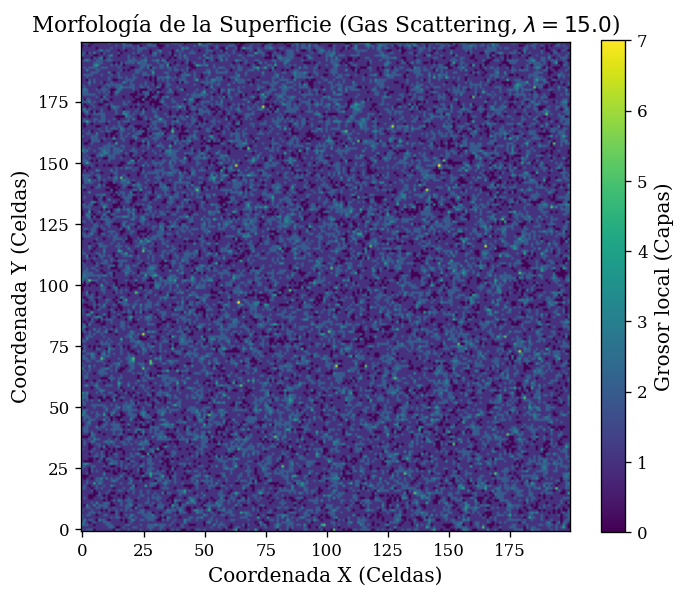

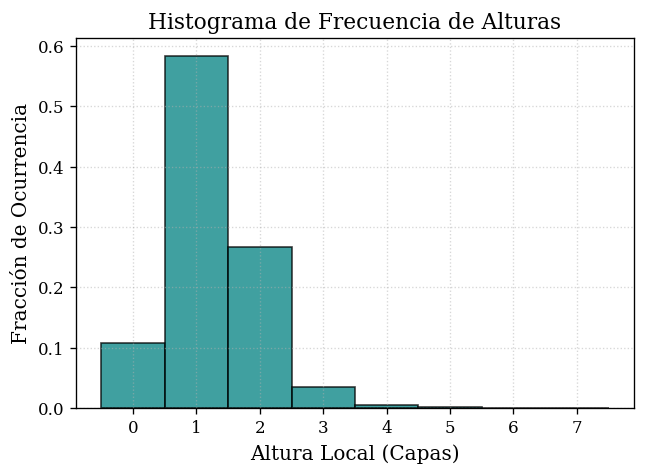

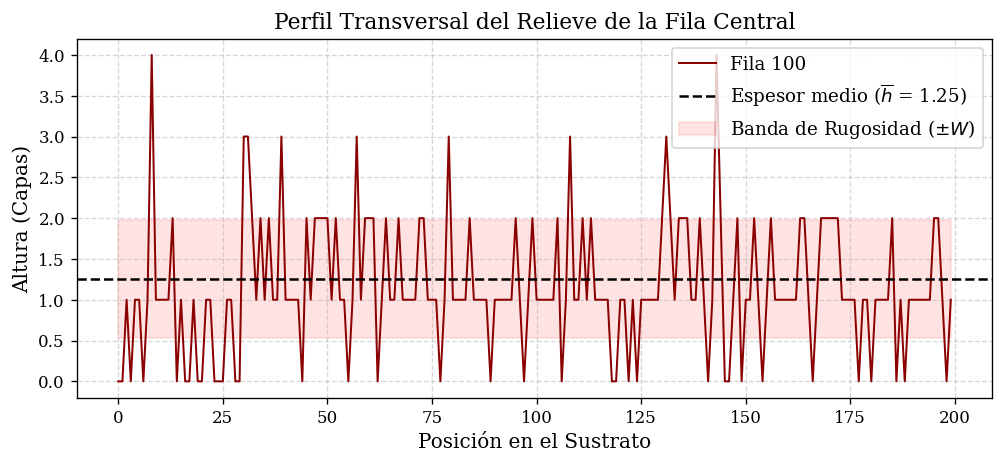

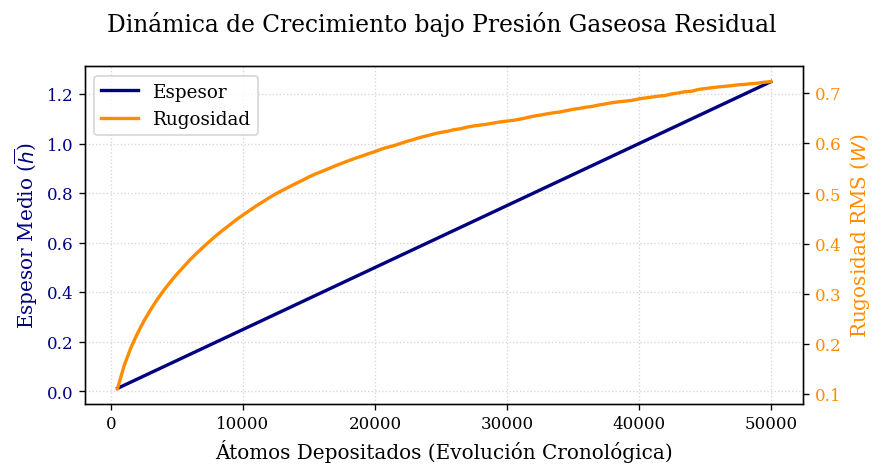

In [4]:
# =============================================================================
# SECCIÓN 6: SIMULACIÓN DIAGNÓSTICA BASE Y EXTRACCIÓN DE LAS 4 FIRMAS
# =============================================================================

print(f"Ejecutando simulación diagnóstica para la condición base (λ = {MEAN_FREE_PATH_BASE})...")
superficie_base, hist_ev, hist_esp, hist_rug = ejecutar_simulacion_scat_historial(
    NX, NY, N_EVENTOS, TEMPERATURE, MAX_DIFFUSION_STEPS, SIGMA_ANGLE_INIT, SIGMA_SCATTERING, MEAN_FREE_PATH_BASE, GUARDAR_CADA
)

print("=" * 65)
print("          MÉTRICAS DE LA PELÍCULA CON DISPERSIÓN EN FASE GASEOSA      ")
print("=" * 65)
print(f"Dimensiones del sustrato : {NX} x {NY} celdas (Toroidal PBC)")
print(f"Partículas depositadas   : {N_EVENTOS}")
print(f"Altura máxima alcanzada  : {np.max(superficie_base)} capas")
print(f"Altura mínima alcanzada  : {np.min(superficie_base)} capas")
print("-" * 65)
print(f"Espesor medio simulado   : {np.mean(superficie_base):.4f} capas")
print(f"Rugosidad RMS simulada   : {np.std(superficie_base):.4f}")
print("=" * 65)

# --- DESPLIEGUE GRÁFICO DE LAS 4 FIRMAS ESTÁNDAR ---

# Firma 1: Topografía Bidimensional (Mapa de Calor)
plt.figure(figsize=(6, 5))
plt.imshow(superficie_base, origin="lower", cmap="viridis")
plt.colorbar(label="Grosor local (Capas)")
plt.xlabel("Coordenada X (Celdas)")
plt.ylabel("Coordenada Y (Celdas)")
plt.title(rf"Morfología de la Superficie (Gas Scattering, $\lambda = {MEAN_FREE_PATH_BASE}$)")
plt.tight_layout()
plt.savefig("scattering_topografia_2d.png", bbox_inches="tight")
plt.show()

# Firma 2: Distribución de Frecuencias de Alturas (Histograma)
plt.figure(figsize=(6, 4))
bins_base = np.arange(np.min(superficie_base), np.max(superficie_base) + 2) - 0.5
plt.hist(superficie_base.ravel(), bins=bins_base, density=True, color="teal", edgecolor="black", alpha=0.75)
plt.xlabel("Altura Local (Capas)")
plt.ylabel("Fracción de Ocurrencia")
plt.title("Histograma de Frecuencia de Alturas")
plt.grid(True, linestyle=":", alpha=0.5)
plt.savefig("scattering_histograma.png", bbox_inches="tight")
plt.show()

# Firma 3: Perfil Transversal Unidimensional Central
fila_central = NX // 2
plt.figure(figsize=(8.5, 4))
plt.plot(superficie_base[fila_central, :], color='darkred', linewidth=1.2, label=f'Fila {fila_central}')
esp_m = np.mean(superficie_base)
rug_m = np.std(superficie_base)
plt.axhline(esp_m, color='black', linestyle='--', label=rf'Espesor medio ($\overline{{h}}$ = {esp_m:.2f})')
plt.fill_between(range(NY), esp_m - rug_m, esp_m + rug_m, color='red', alpha=0.11, label=r'Banda de Rugosidad ($\pm W$)')
plt.title('Perfil Transversal del Relieve de la Fila Central')
plt.xlabel('Posición en el Sustrato')
plt.ylabel('Altura (Capas)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("scattering_perfil_1d.png", bbox_inches="tight")
plt.show()

# Firma 4: Cinética de Crecimiento Temporal (Rugosidad vs Espesor)
fig, ax1 = plt.subplots(figsize=(7.5, 4))
color_esp = 'navy'
ax1.set_xlabel('Átomos Depositados (Evolución Cronológica)')
ax1.set_ylabel(r'Espesor Medio ($\overline{h}$)', color=color_esp)
ax1.plot(hist_ev, hist_esp, color=color_esp, linewidth=2, label='Espesor')
ax1.tick_params(axis='y', labelcolor=color_esp)
ax1.grid(True, linestyle=':', alpha=0.5)

ax2 = ax1.twinx()  
color_rug = 'darkorange'
ax2.set_ylabel(r'Rugosidad RMS ($W$)', color=color_rug)
ax2.plot(hist_ev, hist_rug, color=color_rug, linewidth=2, label='Rugosidad')
ax2.tick_params(axis='y', labelcolor=color_rug)

fig.suptitle('Dinámica de Crecimiento bajo Presión Gaseosa Residual')
fig.tight_layout()
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.savefig("scattering_evolucion_temporal.png", bbox_inches="tight")
plt.show()

In [5]:
# =============================================================================
# SECCIÓN 7: EXPERIMENTO PARAMÉTRICO I — VARIACIÓN DEL CAMINO LIBRE MEDIO (λ)
# =============================================================================

# Definimos valores de λ.
# Valores pequeños (5.0, 10.0) imitan presiones altas (mucho scattering).
# Valores grandes (200.0) imitan UHV/vacío ideal (casi nada de scattering, domina shadowing puro).
CAMINOS_LIBRES_PRUEBA = [5.0, 10.0, 15.0, 30.0, 60.0, 200.0]
REPLICAS_ESTADISTICAS = 3
analisis_mfp = []

for mfp_val in CAMINOS_LIBRES_PRUEBA:
    print(f"Simulando réplicas para Camino Libre Medio λ = {mfp_val} unidades (P ∝ 1/λ)...")
    t_rep, r_rep, max_rep, min_rep = [], [], [], []
    
    for _ in range(REPLICAS_ESTADISTICAS):
        malla = ejecutar_simulacion_scat_completa(
            NX, NY, N_EVENTOS, TEMPERATURE, MAX_DIFFUSION_STEPS, SIGMA_ANGLE_INIT, SIGMA_SCATTERING, mfp_val
        )
        t_rep.append(np.mean(malla))
        r_rep.append(np.std(malla))
        max_rep.append(np.max(malla))
        min_rep.append(np.min(malla))
        
    analisis_mfp.append({
        "Mean Free Path (λ)": mfp_val,
        "Presion Relativa (1/λ)": 1.0 / mfp_val,
        "Espesor medio": np.mean(t_rep),
        "Desviación espesor": np.std(t_rep),
        "Rugosidad media": np.mean(r_rep),
        "Desviación rugosidad": np.std(r_rep),
        "Altura máxima": np.mean(max_rep),
        "Altura mínima": np.mean(min_rep)
    })

df_mfp = pd.DataFrame(analisis_mfp)
df_mfp.round(4)

Simulando réplicas para Camino Libre Medio λ = 5.0 unidades (P ∝ 1/λ)...
Simulando réplicas para Camino Libre Medio λ = 10.0 unidades (P ∝ 1/λ)...
Simulando réplicas para Camino Libre Medio λ = 15.0 unidades (P ∝ 1/λ)...
Simulando réplicas para Camino Libre Medio λ = 30.0 unidades (P ∝ 1/λ)...
Simulando réplicas para Camino Libre Medio λ = 60.0 unidades (P ∝ 1/λ)...
Simulando réplicas para Camino Libre Medio λ = 200.0 unidades (P ∝ 1/λ)...


,Mean Free Path (λ),Presion Relativa (1/λ),Espesor medio,Desviación espesor,Rugosidad media,Desviación rugosidad,Altura máxima,Altura mínima
0,5.0,0.2000,1.25,0.0,0.7788,0.0007,7.6667,0.0
1,10.0,0.1000,1.25,0.0,0.7457,0.0014,7.3333,0.0
2,15.0,0.0667,1.25,0.0,0.7219,0.0040,7.0000,0.0
3,30.0,0.0333,1.25,0.0,0.6940,0.0027,7.0000,0.0
4,60.0,0.0167,1.25,0.0,0.6778,0.0019,6.0000,0.0
5,200.0,0.0050,1.25,0.0,0.6650,0.0037,6.3333,0.0


In [6]:
# =============================================================================
# SECCIÓN 8: EXPERIMENTO PARAMÉTRICO II — LEYES DE ESCALA SEGÚN ESPESOR NOMINAL
# =============================================================================

# Evaluamos la evolución de la rugosidad incrementando el volumen de masa bajo presión constante
VOLUMEN_EVENTOS = [10000, 25000, 50000, 75000]
MFP_ESTUDIO_FIJO = 15.0
analisis_espesores_scat = []

for eventos in VOLUMEN_EVENTOS:
    print(f"Evaluando rugosidad para volumen de {eventos} átomos...")
    r_rep = []
    for _ in range(REPLICAS_ESTADISTICAS):
        malla = ejecutar_simulacion_scat_completa(
            NX, NY, eventos, TEMPERATURE, MAX_DIFFUSION_STEPS, SIGMA_ANGLE_INIT, SIGMA_SCATTERING, MFP_ESTUDIO_FIJO
        )
        r_rep.append(np.std(malla))
        
    analisis_espesores_scat.append({
        "Eventos total": eventos,
        "Espesor Nominal": eventos / (NX * NY),
        "Rugosidad media": np.mean(r_rep),
        "Desviación rugosidad": np.std(r_rep)
    })

df_espesores_scat = pd.DataFrame(analisis_espesores_scat)
df_espesores_scat.round(4)

Evaluando rugosidad para volumen de 10000 átomos...
Evaluando rugosidad para volumen de 25000 átomos...
Evaluando rugosidad para volumen de 50000 átomos...
Evaluando rugosidad para volumen de 75000 átomos...


,Eventos total,Espesor Nominal,Rugosidad media,Desviación rugosidad
0,10000,0.250,0.4591,0.0005
1,25000,0.625,0.6228,0.0022
2,50000,1.250,0.7269,0.0048
3,75000,1.875,0.7959,0.0016


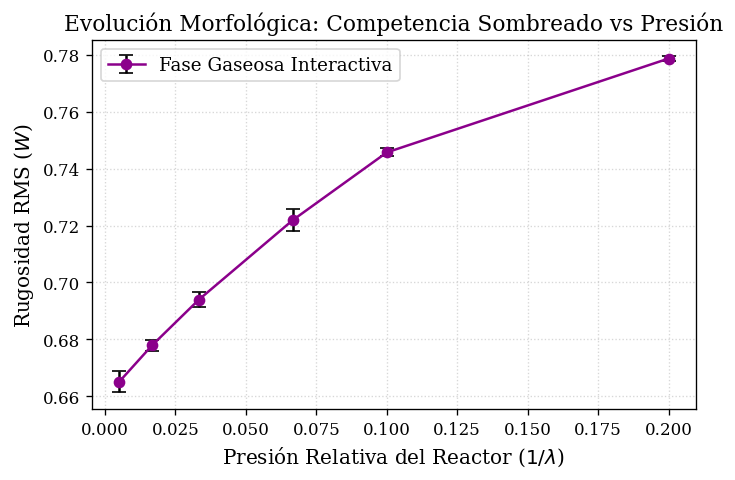

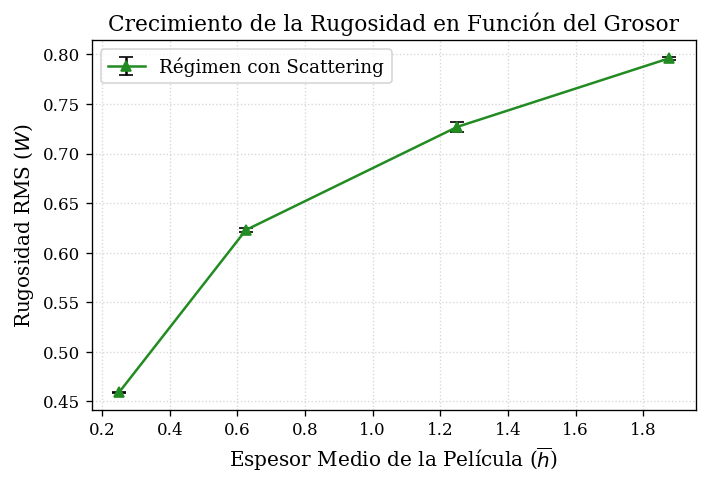

In [7]:
# =============================================================================
# SECCIÓN 9: GENERACIÓN DE CURVAS DE TENDENCIA COLECTIVA
# =============================================================================

# Curva 1: Rugosidad RMS en función de la Presión Relativa (1/λ)
plt.figure(figsize=(6.5, 4))
plt.errorbar(
    df_mfp["Presion Relativa (1/λ)"],
    df_mfp["Rugosidad media"],
    yerr=df_mfp["Desviación rugosidad"],
    fmt="o-",
    color="darkmagenta",
    ecolor="black",
    capsize=4,
    lw=1.5,
    label="Fase Gaseosa Interactiva"
)
plt.xlabel(r"Presión Relativa del Reactor ($1/\lambda$)")
plt.ylabel(r"Rugosidad RMS ($W$)")
plt.title("Evolución Morfológica: Competencia Sombreado vs Presión")
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend()
plt.savefig("scattering_tendencia_presion.png", bbox_inches="tight")
plt.show()

# Curva 2: Ley de escala Rugosidad vs Espesor Nominal con Scattering
plt.figure(figsize=(6.5, 4))
plt.errorbar(
    df_espesores_scat["Espesor Nominal"],
    df_espesores_scat["Rugosidad media"],
    yerr=df_espesores_scat["Desviación rugosidad"],
    fmt="^-",
    color="forestgreen",
    ecolor="black",
    capsize=4,
    lw=1.5,
    label="Régimen con Scattering"
)
plt.xlabel(r"Espesor Medio de la Película ($\overline{h}$)")
plt.ylabel(r"Rugosidad RMS ($W$)")
plt.title("Crecimiento de la Rugosidad en Función del Grosor")
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend()
plt.savefig("scattering_tendencia_espesor.png", bbox_inches="tight")
plt.show()

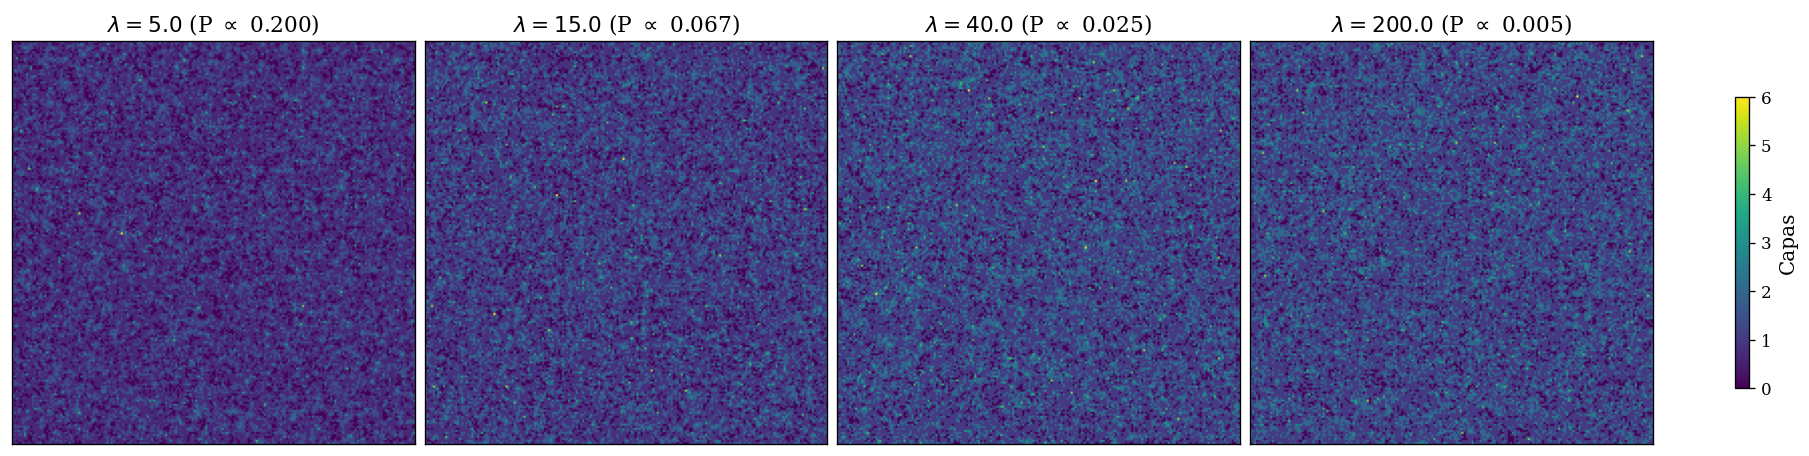

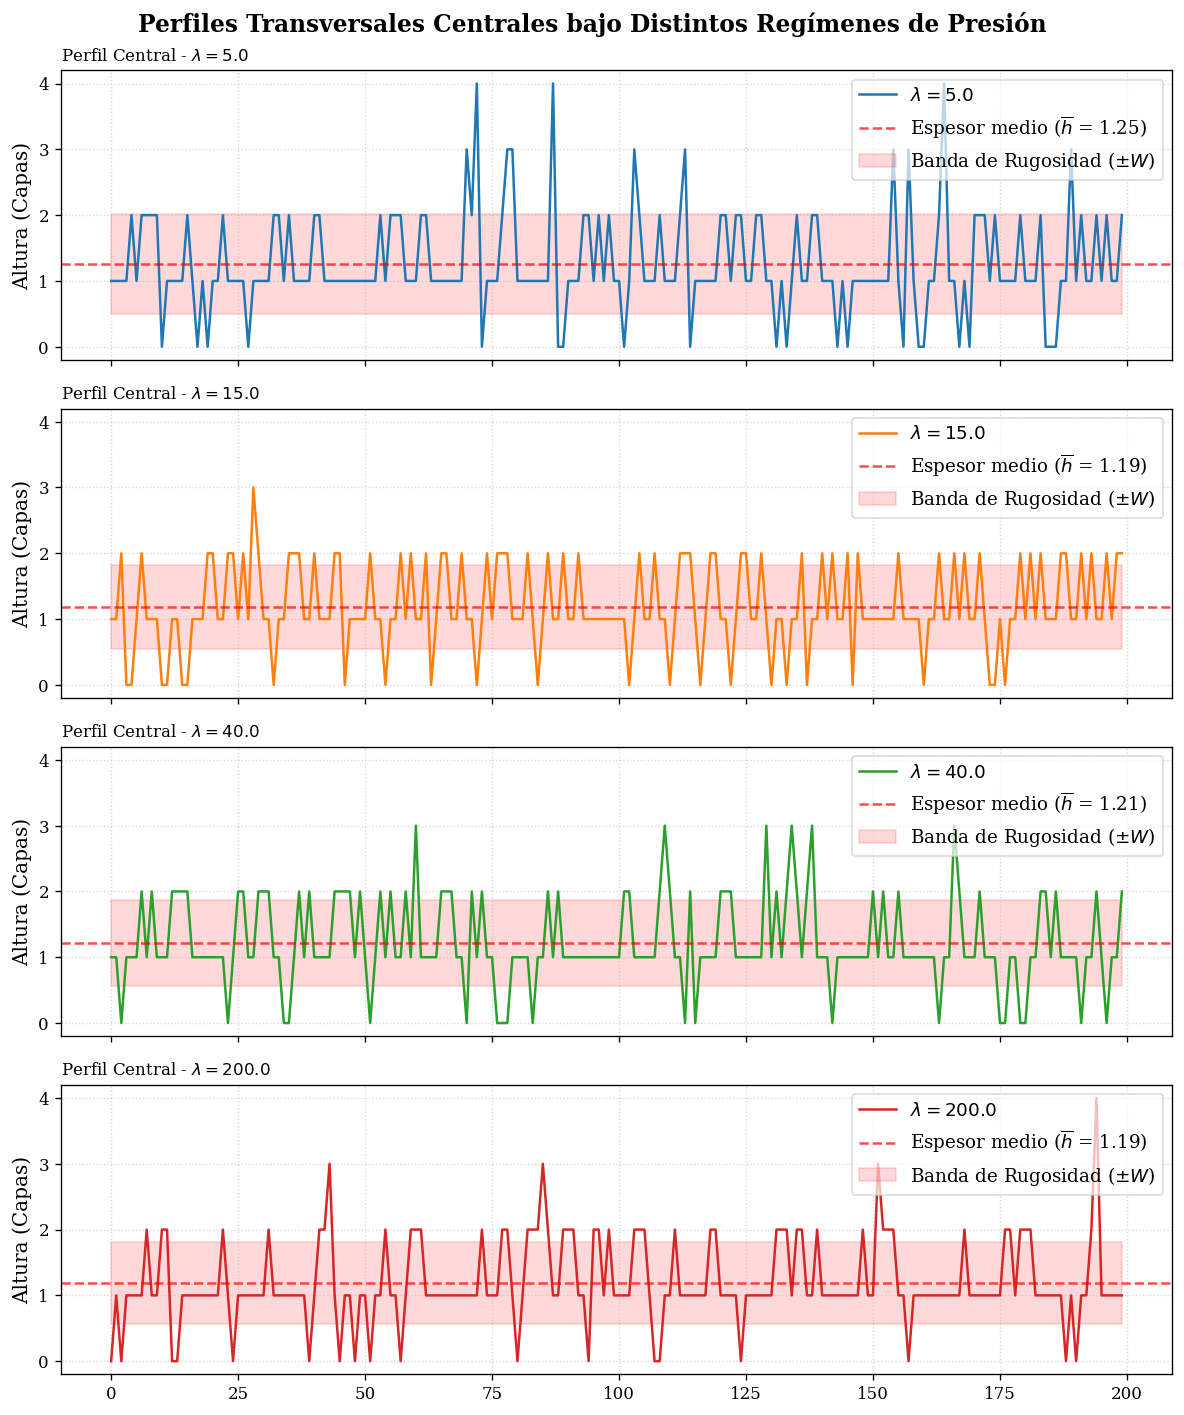

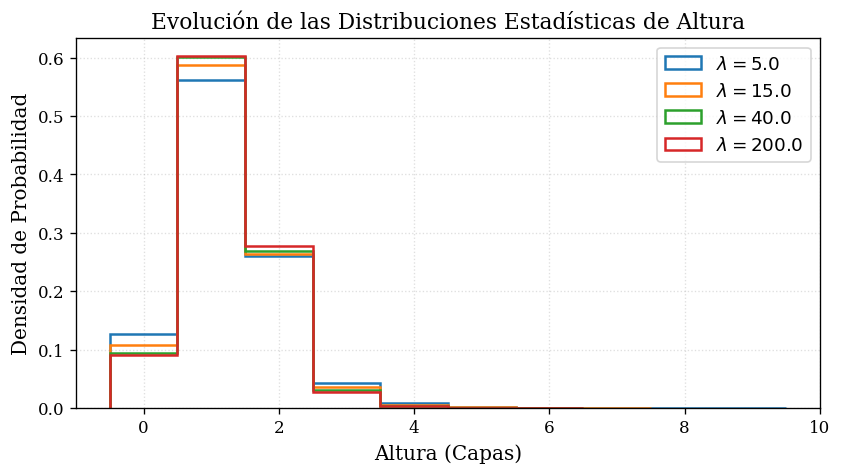

In [8]:
# =============================================================================
# SECCIÓN 10: ESTUDIO VISUAL COMPARATIVO MULTI-PRESIÓN (COMPETENCIA FÍSICA)
# =============================================================================

MFP_COMPARATIVOS = [5.0, 15.0, 40.0, 200.0]
mallas_visuales_scat = []
fila_central = NX // 2   # fila central del sustrato

# Paleta de colores consistente
colores = plt.cm.tab10.colors

# -------------------------------------------------------------------------
# Simulaciones únicas controladas
# -------------------------------------------------------------------------
for mfp_v in MFP_COMPARATIVOS:
    m = ejecutar_simulacion_scat_completa(
        NX, NY, N_EVENTOS, TEMPERATURE, MAX_DIFFUSION_STEPS,
        SIGMA_ANGLE_INIT, SIGMA_SCATTERING, mfp_v
    )
    mallas_visuales_scat.append(m)

# -------------------------------------------------------------------------
# 1. Mapas Topográficos Colectivos
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, len(MFP_COMPARATIVOS), figsize=(15, 3.8), constrained_layout=True)
for ax, m, mfp_v, color in zip(axes, mallas_visuales_scat, MFP_COMPARATIVOS, colores):
    im = ax.imshow(m, origin="lower", cmap="viridis")
    ax.set_title(rf"$\lambda = {mfp_v}$ (P $\propto$ {1/mfp_v:.3f})")
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, shrink=0.7, label="Capas")
plt.savefig("scattering_comparativa_2d.png", bbox_inches="tight")
plt.show()

# -------------------------------------------------------------------------
# 2. Perfiles Centrales (separados por presión, con colores consistentes)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(len(MFP_COMPARATIVOS), 1, figsize=(10, 12), sharex=True, sharey=True)

for ax, m, mfp_v, color in zip(axes, mallas_visuales_scat, MFP_COMPARATIVOS, colores):
    perfil = m[fila_central, :]
    espesor = np.mean(perfil)
    rugosidad = np.std(perfil)

    ax.plot(perfil, lw=1.5, color=color, label=rf"$\lambda = {mfp_v}$")
    ax.axhline(espesor, color="red", linestyle="--", alpha=0.7,
               label=rf"Espesor medio ($\overline{{h}}$ = {espesor:.2f})")
    ax.fill_between(range(NX), espesor - rugosidad, espesor + rugosidad,
                    color="red", alpha=0.15, label=r"Banda de Rugosidad ($\pm W$)")

    ax.set_title(rf"Perfil Central - $\lambda = {mfp_v}$", fontsize=10, loc="left")
    ax.set_ylabel("Altura (Capas)")
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.legend(loc="upper right", framealpha=0.7)

fig.suptitle("Perfiles Transversales Centrales bajo Distintos Regímenes de Presión", fontweight="bold")
plt.tight_layout()
plt.savefig("scattering_comparativa_perfiles_subplots.png", bbox_inches="tight")
plt.show()

# -------------------------------------------------------------------------
# 3. Superposición Dinámica de Histogramas Estadísticos (con mismos colores)
# -------------------------------------------------------------------------
plt.figure(figsize=(8, 4))
for m, mfp_v, color in zip(mallas_visuales_scat, MFP_COMPARATIVOS, colores):
    bins_v = np.arange(m.min(), m.max() + 2) - 0.5
    plt.hist(m.ravel(), bins=bins_v, density=True, histtype="step",
             lw=1.5, color=color, label=rf"$\lambda = {mfp_v}$")
plt.xlabel("Altura (Capas)")
plt.ylabel("Densidad de Probabilidad")
plt.title("Evolución de las Distribuciones Estadísticas de Altura")
plt.grid(True, linestyle=":", alpha=0.4)
plt.legend()
plt.savefig("scattering_comparativa_histogramas.png", bbox_inches="tight")
plt.show()

## 11. Análisis de Resultados

La incorporación de la dispersión en fase gaseosa (*gas-phase scattering*) mediante el camino libre medio ($\lambda$) convierte al simulador en una herramienta predictiva para reactores PVD reales. Los resultados muestran fenómenos cinéticos y termodinámicos de gran relevancia.

### A. Caso Base Transicional ($\lambda = 15.0$)
En la simulación diagnóstica con $\lambda = 15.0$, la distancia fuente-sustrato ($L = 40.0$) es casi tres veces mayor que el camino libre medio ($L/\lambda \approx 2.67$). Esto implica que cada átomo sufre entre 2 y 3 colisiones antes de impactar la superficie.  
* **Métricas globales:** El espesor medio fue de **1.2500 capas** y la rugosidad RMS alcanzó **0.7192**, superior al régimen balístico puro del Notebook 5 ($W = 0.6543$).  
* **Interpretación física:** Las colisiones iniciales desvían los átomos de su trayectoria vertical, ampliando el abanico angular. Esto intensifica el sombreado geométrico en las crestas y genera picos de **7 capas** junto a valles desnudos de **0 capas**.

### B. Firmas Morfológicas Estándar
1. **Mapa 2D y Perfil 1D:** La masa se distribuye homogéneamente gracias a las condiciones periódicas (PBC). El perfil central muestra fluctuaciones de alta frecuencia y amplitud moderada, propias de nucleación perturbada por colisiones.  
2. **Histograma de Alturas:** Exhibe asimetría con predominio en capas bajas (1–2) y una cola extendida hacia 7 capas, confirmando la porosidad del depósito.  
3. **Cinética Temporal:** El espesor medio crece linealmente, mientras que la rugosidad RMS ($W$) aumenta de forma continua sin saturación, evidenciando que las inestabilidades de transporte dominan sobre la relajación térmica a $400\text{ K}$.

### C. Comparativa Multi-Presión: Sombreado vs. Dispersión
La serie de simulaciones con $\lambda = 5.0, 15.0, 40.0, 200.0$ muestra la transición del transporte balístico al difusivo gaseoso:  
* **Alto Vacío / UHV ($\lambda = 200.0$):** El camino libre medio excede ampliamente la cámara ($200 \gg 40$). No hay colisiones y el flujo es balístico. Se forman columnas anchas y profundas, con histogramas muy extendidos que reflejan máxima disparidad topográfica.  
* **Alta Presión / Difusivo ($\lambda = 5.0$):** El camino libre medio es muy corto ($5 \ll 40$). Los átomos sufren múltiples colisiones ($L/\lambda = 8$) y pierden memoria de su dirección inicial. El flujo se vuelve isotrópico, generando **anti-shadowing**: los átomos alcanzan valles antes inaccesibles. El mapa 2D se vuelve homogéneo y suave, el perfil 1D reduce su amplitud y el histograma colapsa en una distribución angosta y simétrica.


## 12. Conclusiones

* **Control morfológico mediante la presión del reactor:** Las simulaciones muestran que la presión de la cámara (inversa al camino libre medio, $\lambda$) funciona como un regulador directo de la porosidad en PVD. En condiciones de bajo vacío ($\lambda \to \infty$), el flujo balístico intensifica el sombreado geométrico y produce películas columnares y rugosas. En cambio, al aumentar la presión ($\lambda \to 0$), las múltiples colisiones isotropizan las trayectorias y suavizan la superficie.

* **Identificación del mecanismo de *anti-shadowing*:** El análisis paramétrico confirmó la aparición del régimen de *anti-shadowing* en condiciones de alta presión ($\lambda = 5.0$). Las colisiones continuas permiten que los átomos rodeen los picos y se depositen en los valles, reduciendo la inestabilidad de crecimiento y favoreciendo películas compactas y homogéneas.

* **Consolidación de la arquitectura modular del simulador:** El Notebook 6 integró todas las etapas físicas del proceso: emisión angular de la fuente, colisiones en fase gaseosa, sombreado balístico y difusión superficial dependiente de la temperatura. Esta estructura modular, optimizada con Numba, demuestra que es posible reproducir dinámicas microscópicas complejas con alta eficiencia estadística, estableciendo las bases para un modelo unificado final.


## 13. Referencias

**Fuentes académicas primarias**

* Ohring, M. (2002). *Materials science of thin films: Deposition and structure* (2nd ed.). Academic Press.

**Recursos complementarios**

* Barabási, A.-L., & Stanley, H. E. (1995). *Fractal concepts in surface growth*. Cambridge University Press.
